Tarea 2

Juan Acevedo Fuentes

2020770859

20-05-2025

**Variable dictionary**

- folio_n20:	identificacion individuo
- year:	anio 20xx
- time:	ronda de la encuesta (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educacion medida en anios completados
- region:	region (1-16)
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 if has kids, 0 ow
- children:	# of children under 18 years old, 18 included
- situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 part-time worker, 2 full-time worker, 0 not working
- exp:	years of labor experience
- size:	tamanio de la firma
- occupation:	codigo ocupacion
- wage:	salario mensual en pesos del anio encuesta
- hours:	horas semanales trabajadas
- informal:	1 if no work contract, 0 ow
- selfemp:	1 if self employed, 0 ow
- publicemp:	1 if worker in public sector, 0 ow
- sistema:	1 if in AFP system, 0 ow
- cotizando:	1 if contributor, 0 ow
- assets:	accumulated wealth in pension system, pesos of each year
- exp_sist:	years of experience in pension system
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene al menos una enferdad, 0 si no
- cronica:	Si tiene enfermedad cronica 1, 0 eoc
- nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- mental:	Si tiene enfermedad mental 1, 0 eoc


Preguntas:

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import pytwoway as tw
import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [167]:
df = pd.read_csv('../../data/panel_eps.csv')
df.reset_index(drop=True, inplace=True)
df = df.set_index(['folio_n20', 'time'])

DFX = df

In [168]:
#Todos los missing de la columna children (cantiada que tiene) se debe a que la gente que indico que no tenia hijos no respondio esa columna
df['children'] = df['children'].fillna(0)

Estudiando los datos, destacamos que se encuentra una gran cantidad de datos faltantes. En la columna children (cantidad de hijos que la persona tiene), había una gran cantidad de datos faltantes, los cuales, al analizar el número, se descubrió que en su totalidad correspondían a personas que respondieron previamente en Kids (¿tiene hijos o no?) de forma negativa, o sea, no poseían hijos en esa ronda y luego decidieron no responder en la columna children. Entonces, todos esos datos faltantes se convirtieron en 0, significando que no tenían hijos.

Cabe destacar que se decidió obviar la columna age (edad), aun siendo un factor importante para el análisis, debido a que la información contenida en la columna no representa verdaderamente la edad de las personas, debido a lo siguiente:

- Solo el 16 % de los datos representan la edad de la persona (los cuales se distribuían entre gente de 20 a 115 años, con una media de 70 años).

- El resto de los datos son años que, al analizarlos y compararlos con los periodos de rondas, se descubrió que representan el año en que se realizó la encuesta (todos los datos de la ronda 1 son 1982-1983; la ronda 2, que fue dos años después, vista en year, corresponde a 1984; y así sucesivamente), lo que significa que para la misma persona, mismo folio, su "edad" cambiaba en cada ronda.

- Eso también nos lleva a concluir que la columna year no representa el año 20XX, sino que 198X-199X, porque → ronda 1 = year 2 = 1982.

Además, para la expectativa de vida, si bien los datos eran correctos, algunos registros presentaban valores como 999 años, los cuales representan valores atípicos (outliers), y para minimizar su ruido se redujo a un máximo de 120 años.

In [169]:
#df_enfermedades = df[['time', 'illness', 'nocronica', 'cronica', 'mental']]
#df_enfermedades = df_enfermedades[df_enfermedades['time'] == 1]
#La explicacion de que enfermedades tiene el individuo
#Para la columna expectancy, que es la expectativa de vida en años. quiero mapear todos los valores superiores a 120 años para que sean solo 100 debido a ser casos atipicos
df['expectancy'] = np.where(df['expectancy'] > 100, 120, df['expectancy'])
df_perdida = df[df['expectancy'].isna()]

In [170]:
#Muuuuy pocas personas respondieron la columna edad correctamente, los demas pusieron el año en que se realizo la encuesta que van desde el año 1982 a 1996 es dificil trabajar con esa data porque no sabemos su edad real
df_edad = df[df['edad'] < 1000]

In [ ]:
df_expectancy = df[df['year'] == 15]
#para la ronda 6 no se calculo la expectativa de vida en ningun caso (100% de missing) entonces para los modelos se eliminaran
df = df[df['year'] != 15]
df = df[df['year'] != 2]
#crear una variable binaria que indique si es el año 2 o 15, en caso contrario es 0ç
#df['dummie_illnes'] = df['year'].map({2:1, 15:1, 4:0, 6:0, 9:0, 12:0})
#No se porque me salta problema al integrar la variable
df['expectancy'].dropna(inplace=True)

Debido a que datos importantes, como la presencia de enfermedades, no se preguntaron en la ronda 1, y en la ronda 6 no existen datos de la expectativa de vida (la cual es nuestra variable dependiente), se optó por eliminar estos dos periodos para los análisis.

In [172]:
#- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
#categorizar
df['is_single'] = df['status'].map({1: 0, 2: 0, 3: 0, 4: 0, 5: 1})
df['is_married'] = df['status'].map({1: 1, 2: 0, 3: 0, 4: 0, 5: 0})
df['is_civil_union'] = df['status'].map({1: 0, 2: 1, 3: 0, 4: 0, 5: 0})
df['is_divorced'] = df['status'].map({1: 0, 2: 0, 3: 1, 4: 0, 5: 0})
df['is_widowed'] = df['status'].map({1: 0, 2: 0, 3: 0, 4: 1, 5: 0})

In [173]:
#Crearemos una variable categorica para saber si es de capital o de otroa parte, con la region metropolitana al tener la mayor cantidad de datos
df['in_capital'] = df['region'].map({13: 1, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 14:0, 15:0})

Para finalizar, se crearon variables categóricas de las columnas status (estado civil de la persona) y region (distribución en regiones de los encuestados)

- Debido a la fuerte tendencia de que la encuesta tiene en su mayoría a personas que viven en la 13ª región (Región Metropolitana), se optó por crear una única variable categórica llamada is_capital, donde 1 representa a quienes viven en la Región Metropolitana (que contiene la capital del país) y 0 en otro caso.

<Axes: xlabel='region'>

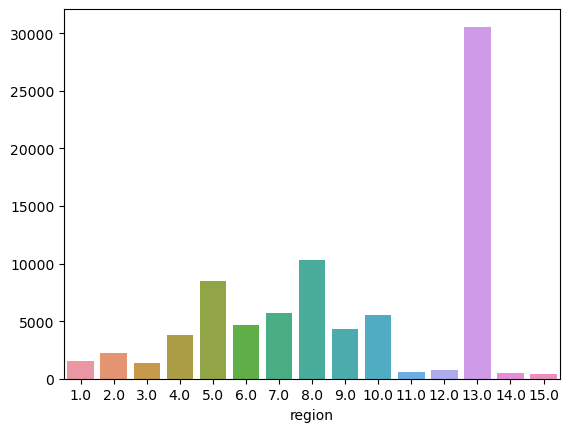

In [174]:
#Crear un barplot que muestre la cantidad de personas por region ordenados de menor a mayor
count = df['region'].value_counts()
sns.barplot(x=count.index, y=count.values)


- Para status se separó en las siguientes variables: [is_single, is_married, is_civil_union, is_divorced, is_widowed], y para los análisis se decidió usar is_single como la columna de referencia.

In [175]:
#Comparamos el estado civil de la persona, con el estado soltero como referencia
y=df['expectancy']
X=df[['is_married','is_civil_union','is_widowed','is_divorced',]]
X=sm.add_constant(X)
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

#se ve como la espectativa de vida que autopercibe la gente es relativamente mayor al tener un estado civil distinto a soltero (excepto el divorciados y union civil no parece ser significativo)
#cabe resalatar que las personas viudas tiener una perspectiva de vida un poco mayor a los demas, posiblmente porque en general los viudos ya son gente adulta con gran cantidad de años
#lo que significa aunque esperen vivir pocos años mas aun asi es son mas años de vida que en otros estados

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.0147
Estimator:              RandomEffects   R-squared (Between):              0.0336
No. Observations:               70222   R-squared (Within):               0.0017
Date:              mar., may. 20 2025   R-squared (Overall):              0.0147
Time:                        20:37:25   Log-likelihood                -2.873e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      262.40
Entities:                       25858   P-value                           0.0000
Avg Obs:                       2.7157   Distribution:                 F(4,70217)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             238.35
                            

Aquí se presenta una regresión de la variable dependiente expectativa de vida y las variables categóricas del estado civil de la persona. Se puede entender en el modelo que las personas en unión civil y divorciadas no son significativas para estimar la expectativa de vida, o sea, que no influyen en su percepción de cuántos años vivirán. Las variables como persona casada o viuda suelen esperar vivir más años. Una explicación simple de por qué ocurre esto con personas viudas es que, para llegar a esa etapa, la mayoría suelen ser personas de mayor edad, por lo tanto, suelen sobrepasar la expectativa de vida promedio o estar cerca de ese umbral, por lo que generalmente su esperanza de vida es unos años mayor, considerando que de por sí ya es superior a 70 años.

Por último, se realizó un mapa de calor entre varias variables para poder encontrar correlación entre ellas y discriminar qué variables usar para los modelos.

<Axes: >

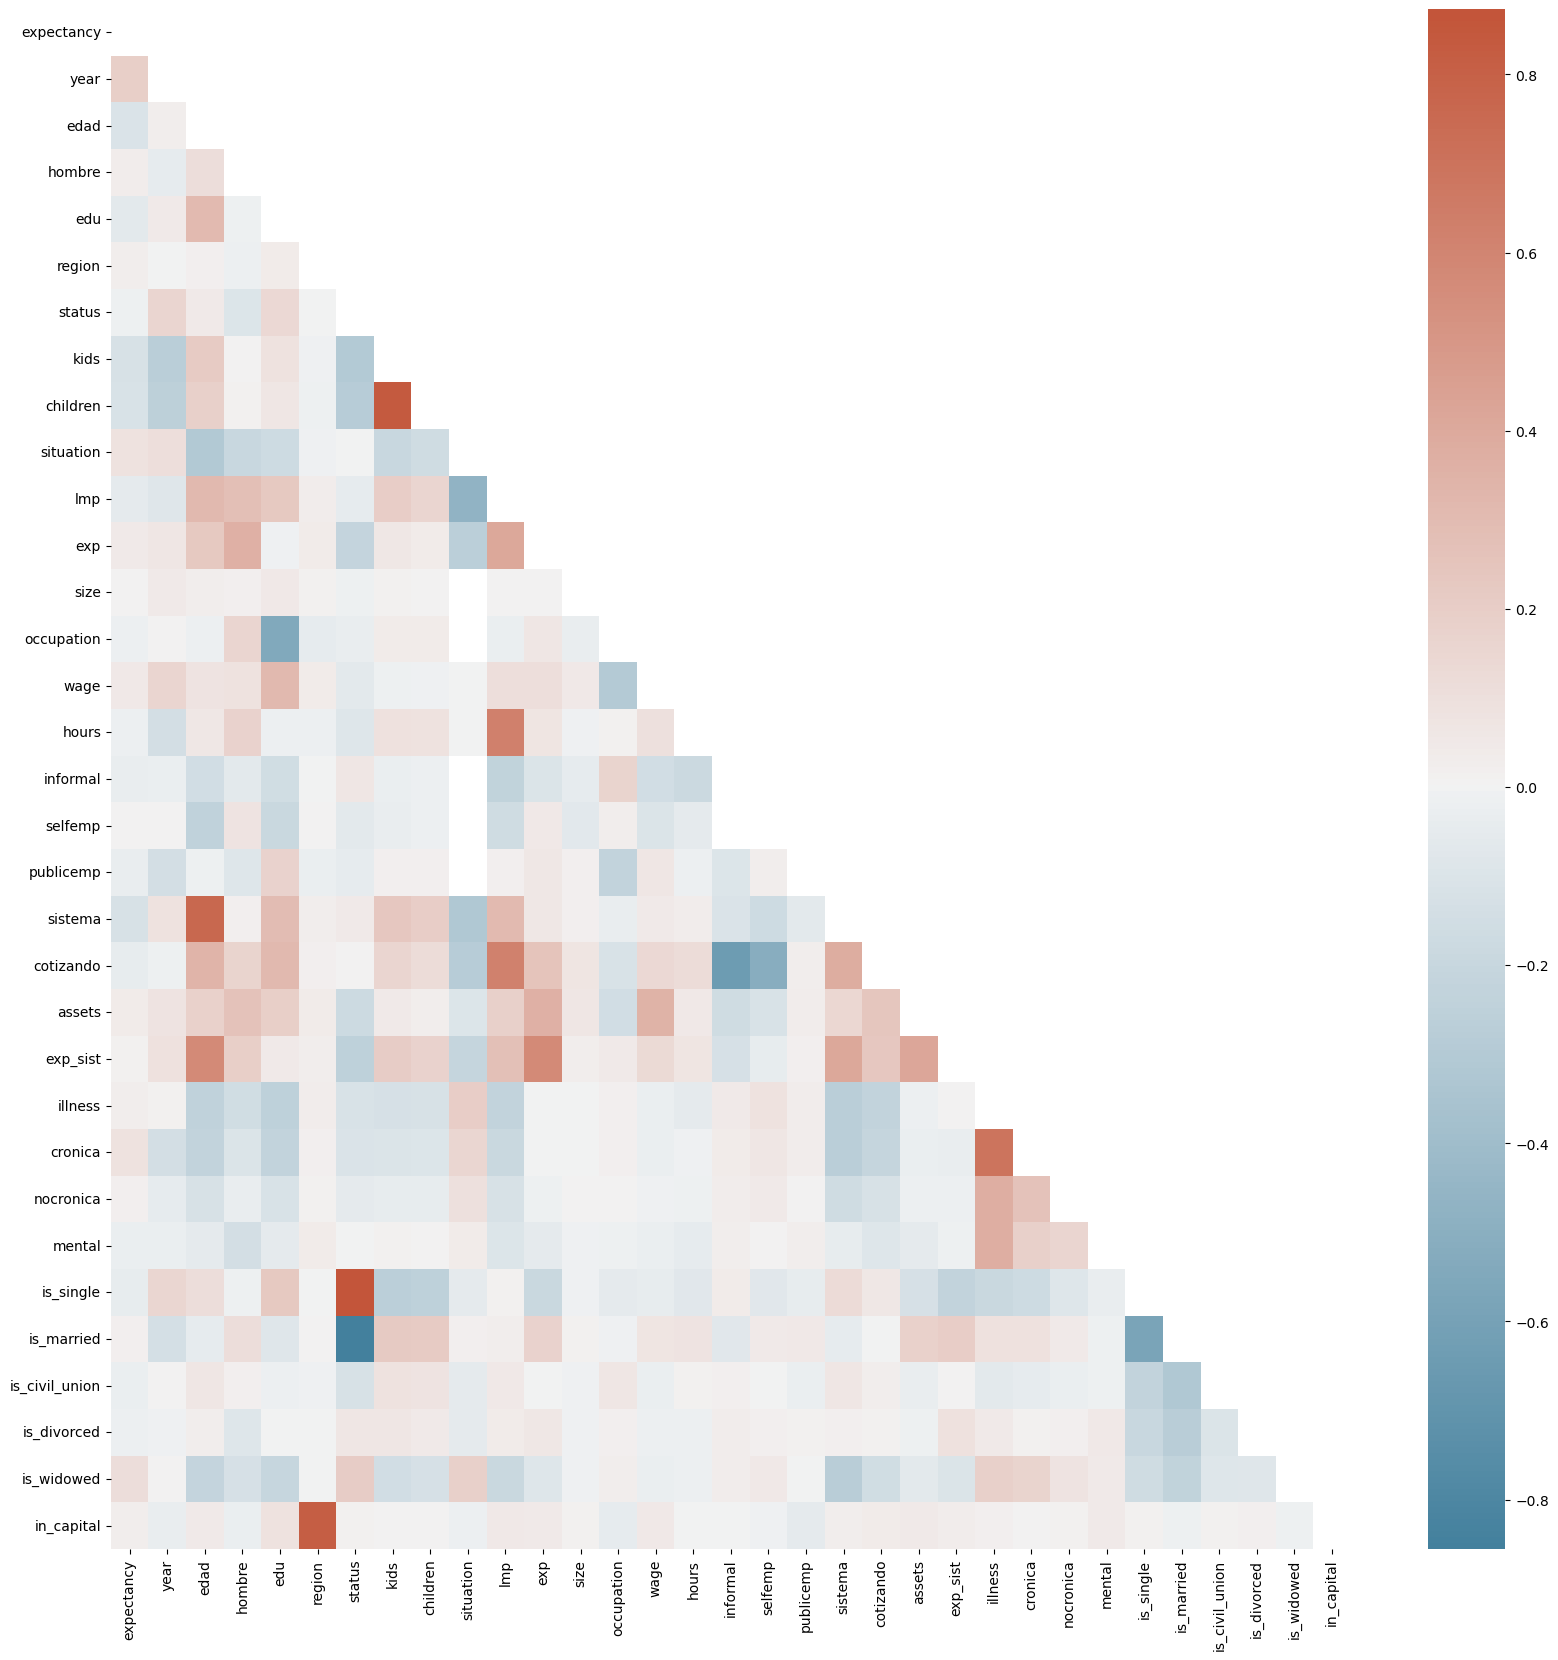

In [176]:
DF = df[['expectancy', 'year',  'edad', 'hombre', 'edu', 'region',
       'status', 'kids', 'children', 'situation', 'lmp', 'exp', 'size',
       'occupation', 'wage', 'hours', 'informal', 'selfemp', 'publicemp',
       'sistema', 'cotizando', 'assets',
       'exp_sist', 'illness', 'cronica',
       'nocronica', 'mental','is_single','is_married','is_civil_union','is_divorced','is_widowed','in_capital']]
corr = DF.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(20, 20))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
#sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.6, center=0,
#            square=True, linewidths=.5, cbar_kws={"shrink": .5})
sns.heatmap(corr, annot=False, cmap=cmap, center=0,mask=mask, )


2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [177]:
#Minimo cuadrado agrupado
y=df['expectancy']
X=df[['edu','hombre','in_capital','kids','is_married','is_civil_union','is_widowed','is_divorced','exp','wage','size', 'selfemp', 'publicemp','sistema', 'cotizando','exp_sist','illness', 'cronica','nocronica', 'mental']]
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0266
Estimator:                   PanelOLS   R-squared (Between):              0.0346
No. Observations:               13326   R-squared (Within):              -0.0021
Date:              mar., may. 20 2025   R-squared (Overall):              0.0266
Time:                        20:37:26   Log-likelihood                -4.987e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      18.198
Entities:                        9470   P-value                           0.0000
Avg Obs:                       1.4072   Distribution:                F(20,13305)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             18.198
                            

Al usar el modelo pooled, vemos que será el peor modelo, ya que no explica suficientemente la variable dependiente. Aspectos como poseer alguna enfermedad o tener una enfermedad crónica no “afectarían” la expectativa de vida de la persona, y en general los parámetros no entregan nada destacable.
He de resaltar que la variable educación no entrega un aporte significativo a medida que aumentan los años de educación.


3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [178]:
X=df[['edu','in_capital','kids','is_married','is_civil_union','is_widowed','is_divorced','exp','selfemp', 'publicemp','sistema', 'cotizando','exp_sist','illness', 'cronica','nocronica', 'mental']]
X=sm.add_constant(X)
model=lmp.PanelOLS(y,X, entity_effects=True)
fe=model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.1811
Estimator:                   PanelOLS   R-squared (Between):             -1.7259
No. Observations:               21272   R-squared (Within):               0.1811
Date:              mar., may. 20 2025   R-squared (Overall):             -1.1500
Time:                        20:37:26   Log-likelihood                -7.754e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      129.65
Entities:                       11288   P-value                           0.0000
Avg Obs:                       1.8845   Distribution:                 F(17,9967)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             86.541
                            

Para el modelo de efecto fijo, vemos un R cuadrado mejor que el del Pooled OLS.
Según el análisis, la constante del modelo nos entrega un valor de 40, lo cual podría interpretarse como que las personas esperan vivir hasta los 40 años (con sus respectivas variaciones según las demás variables). Varias variables presentan un valor p menor a 0.05, lo que significa que no son significativas, posiblemente debido a los supuestos del modelo.

En cuanto a la educación, el coeficiente asociado sugiere una relación negativa con la expectativa de vida. Específicamente, se observa que por cada año adicional de estudio, la expectativa de vida se reduce aproximadamente en un 19 %. Este resultado puede parecer contraintuitivo.


4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

In [179]:
X=df[['edu','in_capital','kids','is_married','is_civil_union','is_widowed','is_divorced','exp', 'selfemp', 'publicemp','sistema', 'cotizando','exp_sist','illness', 'cronica','nocronica', 'mental']]
X=sm.add_constant(X)
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.1482
Estimator:              RandomEffects   R-squared (Between):              0.0139
No. Observations:               21272   R-squared (Within):               0.0579
Date:              mar., may. 20 2025   R-squared (Overall):              0.0267
Time:                        20:37:26   Log-likelihood                -8.607e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      217.52
Entities:                       11288   P-value                           0.0000
Avg Obs:                       1.8845   Distribution:                F(17,21254)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             41.209
                            

Respecto al modelo de efectos aleatorios, se observa un R cuadrado de 0.21, el cual corresponde a la mejor combinación de variables que logré encontrar para este modelo.

Las variables relacionadas con el empleo no parecen ser significativas, en especial el sueldo y el tamaño de las empresas. Sin embargo, es importante recordar que estas variables fueron imputadas, por lo que dicha imputación podría haber afectado los resultados.

La constante del modelo indica que la expectativa de vida ronda los 84 años, y se observa que, a medida que aumentan los años de educación, esta expectativa crece aproximadamente en un 7 %.


5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [180]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 1045.6999034025907, df = 17, p-value = 1.499849542398582e-211


Dado que, según los resultados del test de Hausman, el valor p es menor a 0.05, se rechaza la hipótesis nula, lo que significa que el modelo de efectos fijos es más apropiado para nuestro problema de panel. Esto se debe a que la exogeneidad es distinta de 0, lo cual indica que los errores del modelo están correlacionados con las variables explicativas, posiblemente debido a la falta de variables relevantes o a la distribución de los datos.

In [181]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 21272             21272          13326
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.1811            0.1482         0.0266
R-Squared (Within)              0.1811            0.0579        -0.0021
R-Squared (Between)            -1.7259            0.0139         0.0346
R-Squared (Overall)            -1.1500            0.0267         0.0266
F-statistic                     129.65            217.52         18.198
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

En general, como vemos, los modelos no presentan una alta capacidad explicativa de la variable dependiente. Aun así, con el test de Hausman, podemos concluir que el modelo de efectos fijos es más conveniente de usar, aunque tengo ciertas dudas respecto a su constante, que es bastante baja.


6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [190]:
#X = df.drop(['workers','tamano','fomento','yr_2009','yr_2013','yr_2015','yr_2017'], axis=1, inplace=False)
Xm = X.groupby(by = 'folio_n20').transform('mean')
Xm.columns = ['m_{}'.format(column) for column in Xm.columns]
Xc = pd.merge(df,Xm, left_index=True, right_index=True)
Y = Xc['expectancy']
#print(Xm.columns)
#X seria los valores reales + las medias agrupadas
X = Xc[['edu','in_capital','kids','is_married','is_civil_union','is_widowed','exp','is_divorced', 'selfemp', 'publicemp','sistema', 'cotizando','exp_sist','illness', 'cronica','nocronica', 'mental',
         'm_edu', 'm_in_capital', 'm_kids', 'm_is_married',
       'm_is_civil_union', 'm_is_widowed', 'm_is_divorced','m_exp',
       'm_selfemp', 'm_publicemp', 'm_sistema', 'm_cotizando', 'm_exp_sist',
       'm_illness', 'm_cronica', 'm_nocronica', 'm_mental']]
X=sm.add_constant(X)

model=lmp.RandomEffects(y,X)
cre=model.fit(cov_type="robust")
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.2093
Estimator:              RandomEffects   R-squared (Between):              0.0661
No. Observations:               21272   R-squared (Within):               0.1786
Date:              mar., may. 20 2025   R-squared (Overall):              0.1006
Time:                        20:39:59   Log-likelihood                -8.536e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      165.32
Entities:                       11288   P-value                           0.0000
Avg Obs:                       1.8845   Distribution:                F(34,21237)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             72.794
                            

El modelo de efectos aleatorios correlacionados presenta una mejora respecto a los modelos anteriores, aunque aún se debería estimar la significancia de "k" (según el PPT de la clase, esto es importante para saber si el modelo es equivalente al RE o no, pero no sé cómo hacerlo).

Analizando los valores p del modelo, hay una gran cantidad de variables que no son significativas para el modelo, destacando solo las siguientes: [educación, hijos, los estados civiles excepto el de divorciado, exp_sist, enfermedades mentales y otras medias calculadas].


7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

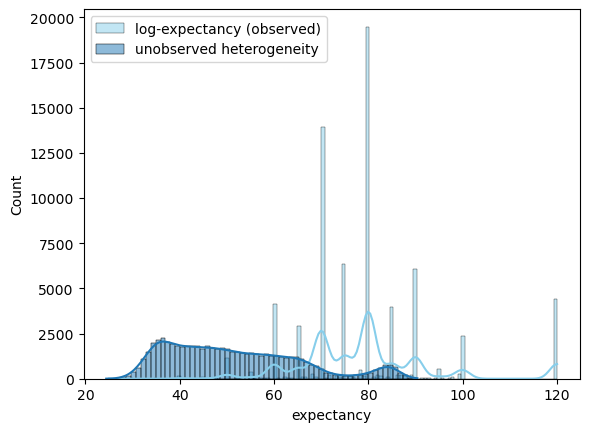

In [191]:
Xpred = X
Xpred['edu']=0
Xpred['in_capital']=0
Xpred['kids']=0
Xpred['is_married']=0
Xpred['is_civil_union']=0
Xpred['is_widowed']=0
Xpred['is_divorced']=0
Xpred['selfemp']=0
Xpred['publicemp']=0
Xpred['sistema']=0
Xpred['cotizando']=0
Xpred['exp_sist']=0
Xpred['illness']=0
Xpred['cronica']=0
Xpred['nocronica']=0
Xpred['mental']=0
yhat = cre.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="log-expectancy (observed)", kde=True)
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True)

plt.legend() 
plt.show()

<!-- La presencia de distintas conecntraciones de resultados puede significar que hay una gran diferencia entre los indivudios que nos haga encontrar subgrupos de personas aunque eso puede deberse a que una gran cantidad de informacion relevante no fue ingresada al modelo (como subgrupos de rango etario de la gente o caracteristicas de cada individuo como el si hacen ejercicios o si tienen vicios) -->

La presencia de varios picos en la data entregada, tanto la observada como la estimada, puede indicarnos la presencia de varios subgrupos dentro de las personas. Esto se debe a que hay una gran cantidad de información relevante no utilizada en el modelo, como la edad, si hacen ejercicio o si tienen vicios pero ademas comparandolo con la predicción podemos ver que nuestro modelo posee errores graves a los datos observados, esa tendencia hacia una espectativa de vida hacia el 0 no deberia existir, posiblemente sea una variable que no logro identificar.

8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

In [184]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco, "CRE": cre}))

                                     Model Comparison                                    
                                    FE                RE         Pooled               CRE
-----------------------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy        expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS     RandomEffects
No. Observations                 21272             21272          13326             21272
Cov. Est.                       Robust            Robust     Unadjusted            Robust
R-squared                       0.1811            0.1482         0.0266            0.2093
R-Squared (Within)              0.1811            0.0579        -0.0021            0.1786
R-Squared (Between)            -1.7259            0.0139         0.0346            0.0661
R-Squared (Overall)            -1.1500            0.0267         0.0266            0.1006
F-statisti

Ante cualquier situación, recomiendo usar este modelo (CRE) o el de efectos fijos. Aunque recomendaría hacer más estudios, trabajando de otras maneras la data y corrigiendo variables claramente significativas para nuestro modelo que no fueron usadas. Además, cabe recordar que la data no estaba balanceada.

9. Bonus track (optativo): Es posible que sus resultados anteriores tengan sesgo dado que quienes esperan vivir mas pueden estar incentivados a adquirir mas educacion. Proponga AL MENOS DOS instrumentos posibles para predecir el nivel de educacion de forma exogena, tal que se pueda corregir el sesgo y entender el efecto causal de las educacion en la expectativa de vida. Realice su estimacion considerando un modelo agrupado (ignorando el tiempo), y el modelo de panel.

R: Hay bastantes características por analizar que no fueron entregadas en la base de datos y que nos permitirían descubrir si la educación es realmente relevante para nuestros resultados. Para medir la educación, además de los años cursados, podría haber información relevante respecto a qué se estudió, calificaciones o incluso que la educación no sea lo más relevante para el individuo y, aun así, presente un alto nivel cognitivo.

Aun así, la esperanza de vida que tiene esa persona también puede estar influenciada por su cultura, familia, historial médico previo o la presencia de vicios y adicciones.